In [1]:
import joblib

X = joblib.load("pkl/X_sparse.pkl")
y = joblib.load("pkl/y.pkl")

print("Shape X:", X.shape)
print("Shape y:", len(y))

Shape X: (1000, 79)
Shape y: 1000


In [2]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [3]:
# Set up Stratified K-Fold cross-validation
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [4]:
# Train a logistic regression model with class weights
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    solver="lbfgs",
    C=5,
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

In [5]:
# Evaluate the model using cross-validation
from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=skf,
    scoring="f1"
)

print("CV F1 scores:", cv_scores)
print("Mean CV F1:", np.mean(cv_scores))
print("Std CV F1:", np.std(cv_scores))

CV F1 scores: [0.98449612 0.98054475 0.98039216 0.984375   0.98832685]
Mean CV F1: 0.9836269752448985
Std CV F1: 0.002945095832635535


In [6]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [8]:
from sklearn.metrics import classification_report, f1_score

print(classification_report(y_test, y_pred))

print("Test F1:", f1_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      1.00      0.90        38
           1       1.00      0.95      0.97       162

    accuracy                           0.96       200
   macro avg       0.91      0.98      0.94       200
weighted avg       0.97      0.96      0.96       200

Test F1: 0.9746835443037974


In [9]:
thresholds = np.linspace(0.1, 0.9, 100)

best_f1 = 0
best_threshold = 0

for t in thresholds:
    y_temp = (y_prob >= t).astype(int)
    f1 = f1_score(y_test, y_temp)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best F1 at best threshold:", best_f1)

Best Threshold: 0.17272727272727273
Best F1 at best threshold: 0.9877300613496932


In [ ]:
joblib.dump(model, "pkl/logistic_regression_model.pkl")

print(" Logistic Regression model saved")

 Logistic model saved


In [11]:
tfidf_skills = joblib.load("pkl/tfidf_skills.pkl")
tfidf_edu = joblib.load("pkl/tfidf_edu.pkl")
tfidf_cert = joblib.load("pkl/tfidf_cert.pkl")
tfidf_job = joblib.load("pkl/tfidf_job.pkl")

feature_names = (
    list(tfidf_skills.get_feature_names_out()) +
    list(tfidf_edu.get_feature_names_out()) +
    list(tfidf_cert.get_feature_names_out()) +
    list(tfidf_job.get_feature_names_out()) +
    ['Experience (Years)', 'Projects Count']
)

coef = model.coef_[0]
indices = np.argsort(np.abs(coef))[::-1]

for i in indices[:20]:
    print(feature_names[i], coef[i])

Experience (Years) 9.870688740092298
Projects Count 5.240592896697556
python deep 2.20411016430187
networking linux 2.170006644779379
google 1.7670633044396395
ml 1.7670633044396395
cybersecurity ethical 1.7491181849709299
specialization 1.5731671007796555
deep 1.5731671007796555
learning 1.5731671007796555
react 1.568254797119386
python machine 1.4922058029708676
react sql 1.347047921311789
nlp tensorflow 1.295553292199717
tensorflow 1.1983605730737943
certified 1.1380772085006554
aws 1.1380772085006554
pytorch python -1.136153630500788
python sql 1.1167532841528618
tensorflow nlp 1.0578249794912529


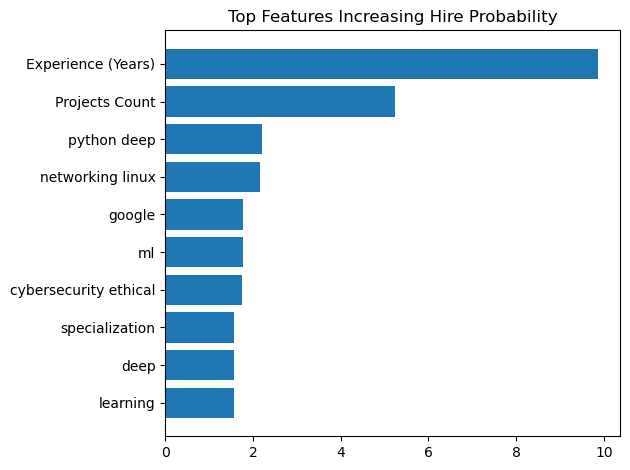

In [12]:
import matplotlib.pyplot as plt

positive_idx = np.argsort(coef)[-10:]

pos_features = [feature_names[i] for i in positive_idx]
pos_values = coef[positive_idx]

plt.figure()
plt.barh(pos_features, pos_values)
plt.title("Top Features Increasing Hire Probability")
plt.tight_layout()
plt.show()